In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [70]:
listings = pd.read_csv("../../../Data/cleaned/Listings_Clean.csv")
listings_fe = listings.copy()

C:\Users\Parv Gupta\AppData\Local\Temp\ipykernel_5180\2621071453.py:1: DtypeWarning: Columns (5,8,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  listings = pd.read_csv("../../../Data/cleaned/Listings_Clean.csv")


# KPI 1 - HostTrust Score

## Candidate Variable Validation

Before constructing the HostTrust Score, each potential variable must be evaluated to determine whether it meaningfully contributes to host reliability.

Instead of assigning arbitrary weights, this project adopts a data-driven approach where every candidate variable is first validated against guest satisfaction.

The objective is to identify which host characteristics have the strongest relationship with guest ratings before incorporating them into the final KPI.

The candidate variables considered are:

- Superhost Status
- Host Response Rate
- Host Response Time
- Host Acceptance Rate
- Identity Verification
- Host Experience

Each variable will be evaluated individually before the HostTrust Score is formulated.

## Valdiation 1- Superhost or Not

In [71]:
listings_fe["host_is_superhost"].value_counts()

host_is_superhost
False    229185
True      50249
Name: count, dtype: int64

In [72]:
listings_fe.groupby("host_is_superhost")["review_scores_rating"].agg(
    ["count", "mean", "median", "std"]
)

,count,mean,median,std
host_is_superhost,,,,
False,142730,92.261410,95.0,11.096962
True,45469,96.996437,98.0,4.029591


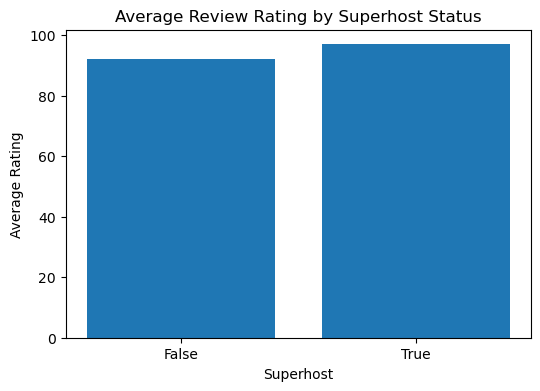

In [73]:
import matplotlib.pyplot as plt

superhost_rating = (
    listings_fe.groupby("host_is_superhost")["review_scores_rating"]
    .mean()
)

plt.figure(figsize=(6,4))
plt.bar(
    superhost_rating.index.astype(str),
    superhost_rating.values
)

plt.title("Average Review Rating by Superhost Status")
plt.xlabel("Superhost")
plt.ylabel("Average Rating")

plt.show()

<Figure size 600x500 with 0 Axes>

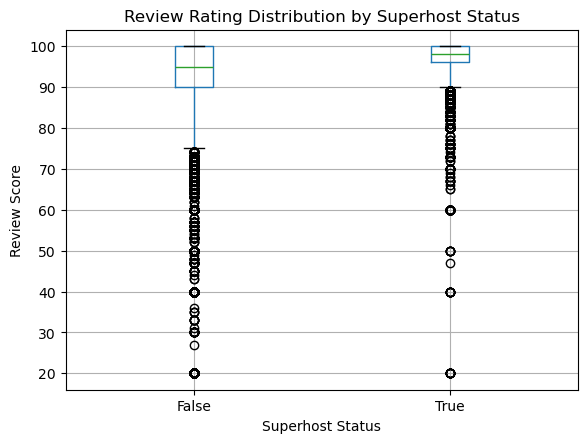

In [74]:
plt.figure(figsize=(6,5))

listings_fe.boxplot(
    column="review_scores_rating",
    by="host_is_superhost"
)

plt.title("Review Rating Distribution by Superhost Status")
plt.suptitle("")  # Removes automatic title
plt.xlabel("Superhost Status")
plt.ylabel("Review Score")

plt.show()

| Variable | Superhost Status |
|----------|------------------|
| Business Relevance | High |
| Evidence Strength | Strong positive relationship with guest ratings and significantly lower rating variability, indicating consistently better guest experiences. |
| Data Reliability | High – Reliable binary feature with no significant quality concerns after data cleaning. |
| Improvement Potential | Medium – Hosts can achieve Superhost status by consistently meeting Airbnb's performance standards. |
| Expected Influence on HostTrust | High |

## Validation 2 – Host Response Rate

In [75]:
listings_fe["host_response_rate"].describe()

count    150898.000000
mean          0.865912
std           0.283768
min           0.000000
25%           0.900000
50%           1.000000
75%           1.000000
max           1.000000
Name: host_response_rate, dtype: float64

In [76]:
listings_fe[
    ["host_response_rate", "review_scores_rating"]
].corr()

,host_response_rate,review_scores_rating
host_response_rate,1.000000,0.112409
review_scores_rating,0.112409,1.000000


In [77]:
listings_fe["host_response_rate_pct"] = (
    listings_fe["host_response_rate"] * 100
)

C:\Users\Parv Gupta\AppData\Local\Temp\ipykernel_5180\3436638526.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("response_rate_group")["review_scores_rating"]


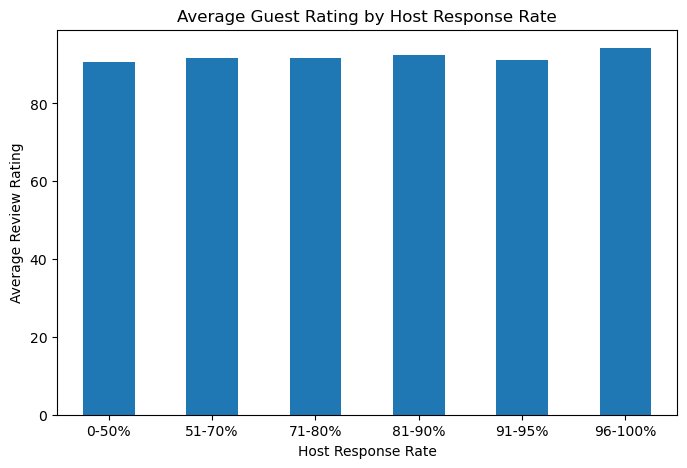

In [78]:
bins = [0, 50, 70, 80, 90, 95, 100]

labels = [
    "0-50%",
    "51-70%",
    "71-80%",
    "81-90%",
    "91-95%",
    "96-100%"
]

listings_fe["response_rate_group"] = pd.cut(
    listings_fe["host_response_rate_pct"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

response_analysis = (
    listings_fe
    .groupby("response_rate_group")["review_scores_rating"]
    .mean()
)

response_analysis.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Guest Rating by Host Response Rate")
plt.xlabel("Host Response Rate")
plt.ylabel("Average Review Rating")
plt.xticks(rotation=0)

plt.show()

| Variable                        | Host Response Rate |
| ------------------------------- | ------------------ |
| Business Relevance              | High               |
| Evidence Strength               | Moderate           |
| Data Reliability                | High               |
| Improvement Potential           | High               |
| Expected Influence on HostTrust | Medium–Low       |


In [79]:
## Validation 3: Responsiveness


In [80]:
listings_fe["host_response_time"].value_counts(dropna=False)

host_response_time
NaN                   128701
within an hour         83434
within a few hours     28891
within a day           23423
a few days or more     15150
Name: count, dtype: int64

In [81]:
response_time_analysis = (
    listings_fe
    .groupby("host_response_time")["review_scores_rating"]
    .agg(["count","mean","median","std"])
)

response_time_analysis

,count,mean,median,std
host_response_time,,,,
a few days or more,7966,90.424429,95.0,14.985827
within a day,16124,93.513520,96.0,9.862825
within a few hours,21209,93.906879,97.0,9.093948
within an hour,65785,93.804804,96.0,8.891245


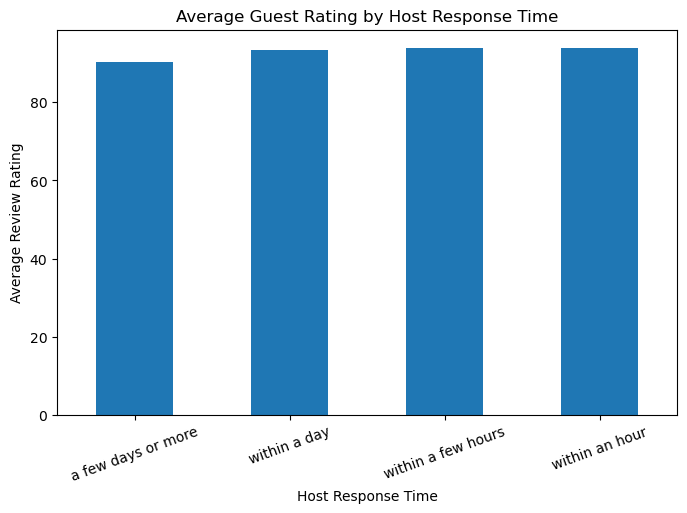

In [82]:
response_time_analysis["mean"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Guest Rating by Host Response Time")
plt.xlabel("Host Response Time")
plt.ylabel("Average Review Rating")
plt.xticks(rotation=20)

plt.show()

| Variable                        | Host Response Time |
| ------------------------------- | ------------------ |
| Business Relevance              | High               |
| Observed Impact                 | Moderate–Strong    |
| Data Reliability                | High               |
| Improvement Potential           | High               |
| Expected Influence on HostTrust | Medium             |


## Validation 4: Host Acceptance Rate

In [83]:
listings_fe["host_acceptance_rate"].describe()

count    166577.000000
mean          0.827123
std           0.289231
min           0.000000
25%           0.780000
50%           0.980000
75%           1.000000
max           1.000000
Name: host_acceptance_rate, dtype: float64

In [84]:
listings_fe[
    ["host_acceptance_rate", "review_scores_rating"]
].corr()

,host_acceptance_rate,review_scores_rating
host_acceptance_rate,1.000000,-0.017294
review_scores_rating,-0.017294,1.000000


In [85]:
listings_fe["acceptance_rate_pct"] = (
    listings_fe["host_acceptance_rate"] * 100
)

bins = [0, 50, 70, 80, 90, 95, 100]

labels = [
    "0-50%",
    "51-70%",
    "71-80%",
    "81-90%",
    "91-95%",
    "96-100%"
]

listings_fe["acceptance_rate_group"] = pd.cut(
    listings_fe["acceptance_rate_pct"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

acceptance_analysis = (
    listings_fe
    .groupby("acceptance_rate_group")["review_scores_rating"]
    .agg(["count","mean","median","std"])
)

acceptance_analysis

C:\Users\Parv Gupta\AppData\Local\Temp\ipykernel_5180\2264260229.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("acceptance_rate_group")["review_scores_rating"]


,count,mean,median,std
acceptance_rate_group,,,,
0-50%,16165,94.047324,97.0,9.635644
51-70%,7113,93.920427,97.0,9.618547
71-80%,7400,93.921216,97.0,9.254734
81-90%,11060,93.514557,96.0,9.190190
91-95%,10311,93.095141,96.0,9.641718
96-100%,76946,93.580537,96.0,9.458687


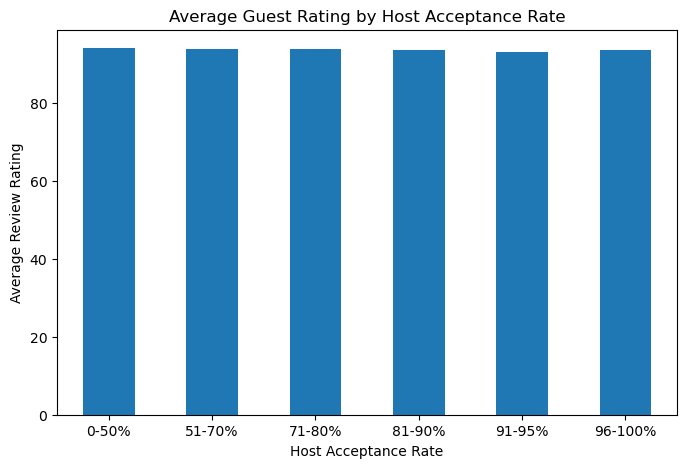

In [86]:
acceptance_analysis["mean"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Guest Rating by Host Acceptance Rate")
plt.xlabel("Host Acceptance Rate")
plt.ylabel("Average Review Rating")
plt.xticks(rotation=0)

plt.show()

| Variable                        | Host Acceptance Rate |
| ------------------------------- | -------------------- |
| Business Relevance              | Medium               |
| Observed Impact                 | Weak                 |
| Data Reliability                | High                 |
| Improvement Potential           | Medium               |
| Expected Influence on HostTrust | Low                  |


## Validation 5: Identity Verification


In [87]:
listings_fe["host_identity_verified"].value_counts(dropna=False)

host_identity_verified
True     201098
False     78336
NaN         165
Name: count, dtype: int64

In [88]:
identity_analysis = (
    listings_fe
    .groupby("host_identity_verified")["review_scores_rating"]
    .agg(["count", "mean", "median", "std"])
)

identity_analysis

,count,mean,median,std
host_identity_verified,,,,
False,41595,92.464238,97.0,12.413104
True,146604,93.672424,96.0,9.282174


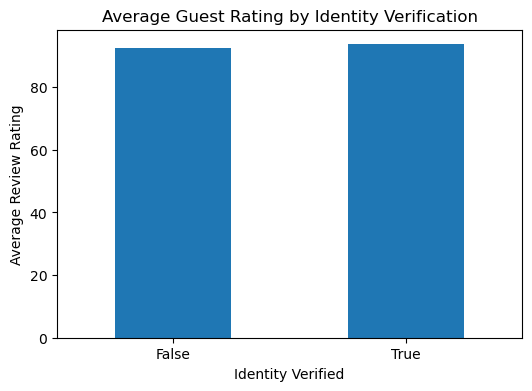

In [89]:
identity_analysis["mean"].plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Average Guest Rating by Identity Verification")
plt.xlabel("Identity Verified")
plt.ylabel("Average Review Rating")
plt.xticks(rotation=0)

plt.show()

| Variable                        | Host Identity Verified |
| ------------------------------- | ---------------------- |
| Business Relevance              | High                   |
| Observed Impact                 | Moderate               |
| Data Reliability                | High                   |
| Improvement Potential           | Low                    |
| Expected Influence on HostTrust | Medium                 |


## Validation 6: Host Experience


In [90]:
listings_fe["host_since"] = pd.to_datetime(listings_fe["host_since"])

today = pd.Timestamp.today()

listings_fe["host_experience_years"] = (
    (today - listings_fe["host_since"]).dt.days / 365.25
)

In [91]:
listings_fe["host_experience_years"].describe()

count    279434.000000
mean         10.236863
std           2.436356
min           5.357974
25%           8.243669
50%          10.392882
75%          12.019165
max          17.900068
Name: host_experience_years, dtype: float64

In [92]:
bins = [5, 7, 9, 11, 13, 18]

labels = [
    "5-7 Years",
    "7-9 Years",
    "9-11 Years",
    "11-13 Years",
    "13+ Years"
]

listings_fe["experience_group"] = pd.cut(
    listings_fe["host_experience_years"],
    bins=bins,
    labels=labels,
    include_lowest=True
)
experience_analysis = (
    listings_fe
    .groupby("experience_group")["review_scores_rating"]
    .agg(["count", "mean", "median", "std"])
)

experience_analysis

C:\Users\Parv Gupta\AppData\Local\Temp\ipykernel_5180\1706228370.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("experience_group")["review_scores_rating"]


,count,mean,median,std
experience_group,,,,
5-7 Years,16211,91.202702,97.0,14.680525
7-9 Years,35667,92.499565,96.0,11.817652
9-11 Years,54053,93.719257,97.0,9.596477
11-13 Years,53495,94.001383,96.0,8.328501
13+ Years,28773,94.071595,96.0,7.864491


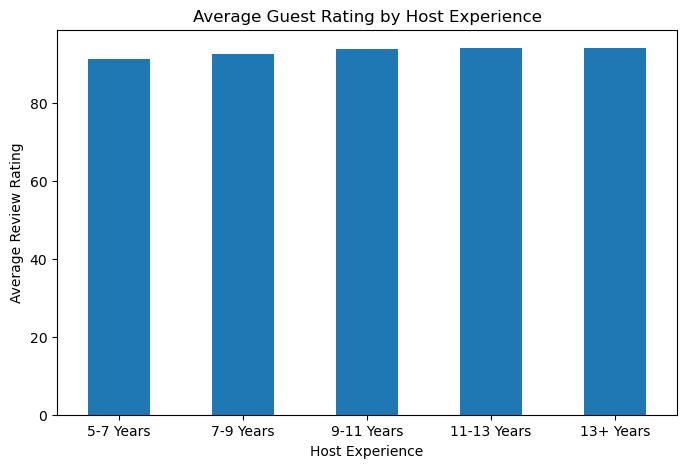

In [93]:
experience_analysis["mean"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Guest Rating by Host Experience")
plt.xlabel("Host Experience")
plt.ylabel("Average Review Rating")
plt.xticks(rotation=0)

plt.show()

| Variable                        | Host Experience |
| ------------------------------- | --------------- |
| Business Relevance              | High            |
| Observed Impact                 | Strong          |
| Data Reliability                | High            |
| Improvement Potential           | Low             |
| Expected Influence on HostTrust | High            |


## Final Observations

| Variable               | Business Relevance | Observed Impact   | Data Reliability | Improvement Potential | Expected Influence |
| ---------------------- | ------------------ | ----------------- | ---------------- | --------------------- | ------------------ |
| Superhost Status       | High               | **Strong**        | High             | Medium                | **High**           |
| Host Response Rate     | High               | **Weak–Moderate** | High             | High                  | **Medium**         |
| Host Response Time     | High               | **Strong**        | High             | High                  | **High**           |
| Host Acceptance Rate   | High               | **Weak**          | High             | Medium                | **Low**            |
| Host Identity Verified | High               | **Moderate**      | High             | Low                   | **Medium**         |
| Host Experience        | High               | **Strong**        | High             | Low                   | **High**           |


In [94]:
features = [
    "host_is_superhost",
    "host_response_rate",
    "host_response_time",
    "host_acceptance_rate",
    "host_identity_verified",
    "host_experience_years"
]

target = "review_scores_rating"

In [95]:
rf_data = listings_fe[features + [target]].copy()


In [96]:
print(rf_data["host_is_superhost"].unique())
print(rf_data["host_identity_verified"].unique())

[False True nan]
[False True nan]


In [97]:
rf_data = rf_data.dropna()

In [98]:
rf_data.isna().sum()

host_is_superhost         0
host_response_rate        0
host_response_time        0
host_acceptance_rate      0
host_identity_verified    0
host_experience_years     0
review_scores_rating      0
dtype: int64

In [99]:
rf_data["host_is_superhost"] = rf_data["host_is_superhost"].astype(int)
rf_data["host_identity_verified"] = rf_data["host_identity_verified"].astype(int)

In [100]:
rf_data = listings_fe[features + [target]].copy()

rf_data = rf_data.dropna()

print(rf_data.isna().sum())

print(rf_data["host_is_superhost"].unique())
print(rf_data["host_identity_verified"].unique())

host_is_superhost         0
host_response_rate        0
host_response_time        0
host_acceptance_rate      0
host_identity_verified    0
host_experience_years     0
review_scores_rating      0
dtype: int64
[False True]
[True False]


In [101]:
rf_data["host_is_superhost"] = rf_data["host_is_superhost"].astype(int)
rf_data["host_identity_verified"] = rf_data["host_identity_verified"].astype(int)

In [102]:
rf_data = pd.get_dummies(
    rf_data,
    columns=["host_response_time"],
    drop_first=True
)

In [103]:
from sklearn.ensemble import RandomForestRegressor

X = rf_data.drop(columns=target)
y = rf_data[target]

rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

,n_estimators,500
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [104]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
4,host_experience_years,0.592025
2,host_acceptance_rate,0.120756
0,host_is_superhost,0.104274
1,host_response_rate,0.095272
3,host_identity_verified,0.038479
6,host_response_time_within a few hours,0.017222
7,host_response_time_within an hour,0.017100
5,host_response_time_within a day,0.014873


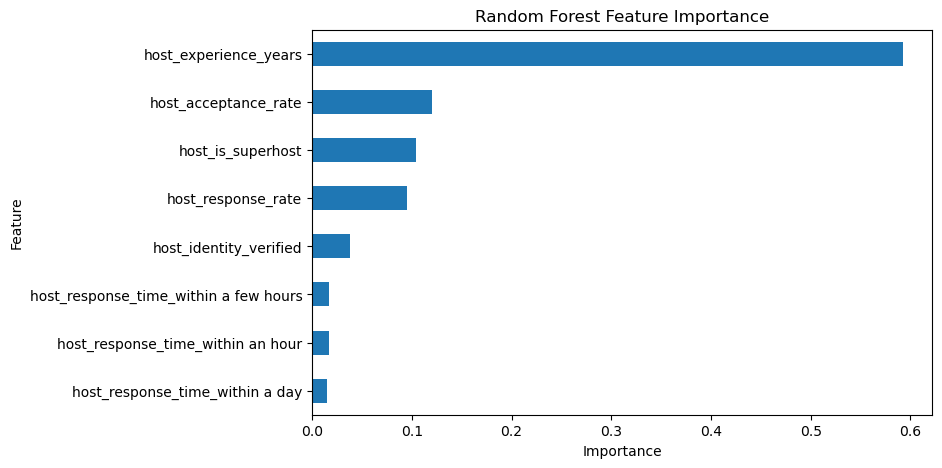

In [105]:
importance.plot.barh(
    x="Feature",
    y="Importance",
    figsize=(8,5),
    legend=False
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.show()

In [106]:
from sklearn.model_selection import train_test_split

from sklearn.inspection import permutation_importance

In [107]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [108]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,n_estimators,500
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [109]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

In [110]:
perm_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm.importances_mean
}).sort_values(
    by="Importance",
    ascending=False
)

perm_importance

,Feature,Importance
0,host_is_superhost,0.145683
4,host_experience_years,0.121979
1,host_response_rate,0.095147
2,host_acceptance_rate,0.071392
3,host_identity_verified,0.006462
5,host_response_time_within a day,-0.009214
7,host_response_time_within an hour,-0.009925
6,host_response_time_within a few hours,-0.010046


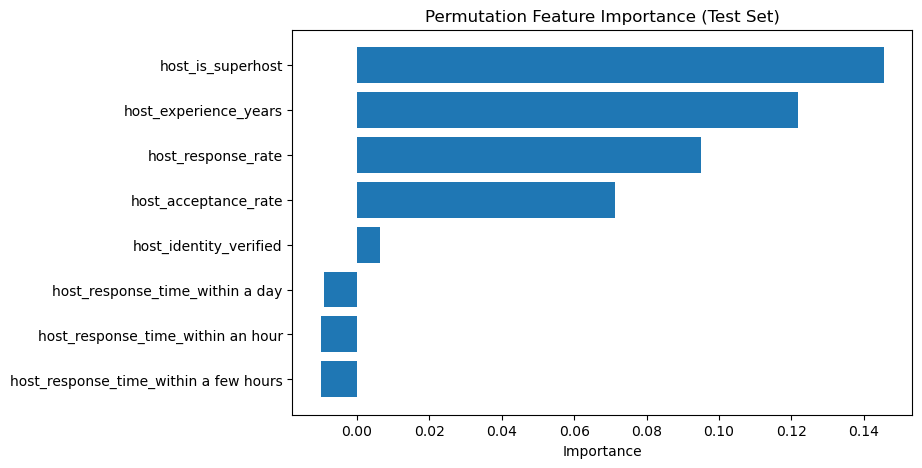

In [111]:
plt.figure(figsize=(8,5))

plt.barh(
    perm_importance["Feature"],
    perm_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Permutation Feature Importance (Test Set)")
plt.xlabel("Importance")

plt.show()

| Variable               | Expected Influence | EDA Score |
| ---------------------- | ------------------ | --------: |
| Host Experience        | High               |  **1.00** |
| Superhost Status       | High               |  **1.00** |
| Host Response Time     | High               |  **1.00** |
| Host Response Rate     | Medium             |  **0.60** |
| Host Identity Verified | Medium             |  **0.60** |
| Host Acceptance Rate   | Low                |  **0.30** |


In [112]:
eda_scores = pd.DataFrame({
    "Variable": [
        "host_experience_years",
        "host_is_superhost",
        "host_response_time",
        "host_response_rate",
        "host_identity_verified",
        "host_acceptance_rate"
    ],
    "EDA_Score": [
        1.0,
        1.0,
        1.0,
        0.6,
        0.6,
        0.3
    ]
})

eda_scores["EDA_Normalized"] = (
    eda_scores["EDA_Score"] /
    eda_scores["EDA_Score"].sum()
)

In [113]:
importance["Variable"] = importance["Feature"]

rf_grouped = (
    importance
    .assign(
        Variable=lambda df: df["Variable"].replace({
            "host_response_time_within an hour": "host_response_time",
            "host_response_time_within a few hours": "host_response_time",
            "host_response_time_within a day": "host_response_time"
        })
    )
    .groupby("Variable", as_index=False)["Importance"]
    .sum()
)

rf_grouped

,Variable,Importance
0,host_acceptance_rate,0.120756
1,host_experience_years,0.592025
2,host_identity_verified,0.038479
3,host_is_superhost,0.104274
4,host_response_rate,0.095272
5,host_response_time,0.049194


In [114]:
perm_importance["Variable"] = perm_importance["Feature"]

perm_grouped = (
    perm_importance
    .assign(
        Variable=lambda df: df["Variable"].replace({
            "host_response_time_within an hour": "host_response_time",
            "host_response_time_within a few hours": "host_response_time",
            "host_response_time_within a day": "host_response_time"
        })
    )
    .groupby("Variable", as_index=False)["Importance"]
    .sum()
)

perm_grouped

,Variable,Importance
0,host_acceptance_rate,0.071392
1,host_experience_years,0.121979
2,host_identity_verified,0.006462
3,host_is_superhost,0.145683
4,host_response_rate,0.095147
5,host_response_time,-0.029185


In [115]:
weights = (
    rf_grouped
    .merge(
        perm_grouped,
        on="Variable",
        suffixes=("_RF", "_Permutation")
    )
    .merge(
        eda_scores[["Variable","EDA_Normalized"]],
        on="Variable"
    )
)

In [116]:
weights["Composite_Score"] = (
      0.30 * weights["Importance_RF"]
    + 0.60 * weights["Importance_Permutation"]
    + 0.10 * weights["EDA_Normalized"]
)

In [117]:
weights["Final_Weight"] = (
    weights["Composite_Score"] /
    weights["Composite_Score"].sum()
) * 100

weights = weights.sort_values(
    "Final_Weight",
    ascending=False
)

weights

,Variable,Importance_RF,Importance_Permutation,EDA_Normalized,Composite_Score,Final_Weight
1,host_experience_years,0.592025,0.121979,0.222222,0.273017,42.204795
3,host_is_superhost,0.104274,0.145683,0.222222,0.140914,21.783435
4,host_response_rate,0.095272,0.095147,0.133333,0.099003,15.304504
0,host_acceptance_rate,0.120756,0.071392,0.066667,0.085729,13.252528
2,host_identity_verified,0.038479,0.006462,0.133333,0.028754,4.445036
5,host_response_time,0.049194,-0.029185,0.222222,0.019469,3.009702


In [118]:
min_exp = listings_fe["host_experience_years"].min()
max_exp = listings_fe["host_experience_years"].max()

listings_fe["host_experience_score"] = (
    (listings_fe["host_experience_years"] - min_exp)
    /
    (max_exp - min_exp)
)

In [119]:
listings_fe["host_response_rate_score"] = (
    listings_fe["host_response_rate"] / 100
)

In [120]:
listings_fe["host_acceptance_rate_score"] = (
    listings_fe["host_acceptance_rate"] / 100
)

In [121]:
listings_fe["superhost_score"] = (
    listings_fe["host_is_superhost"]
    .fillna(False)
    .astype(int)
)

C:\Users\Parv Gupta\AppData\Local\Temp\ipykernel_5180\3950950781.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


In [122]:
listings_fe["identity_score"] = (
    listings_fe["host_identity_verified"]
    .fillna(False)
    .astype(int)
)

C:\Users\Parv Gupta\AppData\Local\Temp\ipykernel_5180\2501485813.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


In [123]:
response_time_mapping = {
    "within an hour": 1.00,
    "within a few hours": 0.75,
    "within a day": 0.50,
    "a few days or more": 0.25
}

listings_fe["response_time_score"] = (
    listings_fe["host_response_time"]
    .map(response_time_mapping)
)

In [124]:
component_weights = {
    "host_experience_score": 0.4229,
    "superhost_score": 0.2172,
    "host_response_rate_score": 0.1533,
    "host_acceptance_rate_score": 0.1316,
    "identity_score": 0.0446,
    "response_time_score": 0.0304
}

def compute_hosttrust(row):
    available = {k: v for k, v in component_weights.items() if pd.notna(row[k])}
    if not available:
        return np.nan
    weight_sum = sum(available.values())
    score = sum(row[k] * (v / weight_sum) for k, v in available.items())
    return score * 100

listings_fe["HostTrust"] = listings_fe.apply(compute_hosttrust, axis=1)
listings_fe["HostTrust_Components_Used"] = listings_fe[list(component_weights.keys())].notna().sum(axis=1)

In [125]:
print("Missing HostTrust:", listings_fe["HostTrust"].isna().sum())
listings_fe["HostTrust_Components_Used"].value_counts().sort_index()

Missing HostTrust: 0


HostTrust_Components_Used
2       165
3     96939
4     31597
5     15918
6    134980
Name: count, dtype: int64

In [126]:
listings_fe = listings_fe[listings_fe["HostTrust_Components_Used"] >= 3].copy()

print("Rows remaining:", len(listings_fe))
print("Missing HostTrust:", listings_fe["HostTrust"].isna().sum())
listings_fe["HostTrust_Components_Used"].value_counts().sort_index()

Rows remaining: 279434
Missing HostTrust: 0


HostTrust_Components_Used
3     96939
4     31597
5     15918
6    134980
Name: count, dtype: int64

In [127]:
listings_fe["HostTrust"].describe()

count    279434.000000
mean         29.080200
std          14.156633
min           0.013483
25%          17.985930
50%          28.328820
75%          38.272440
max          95.955188
Name: HostTrust, dtype: float64

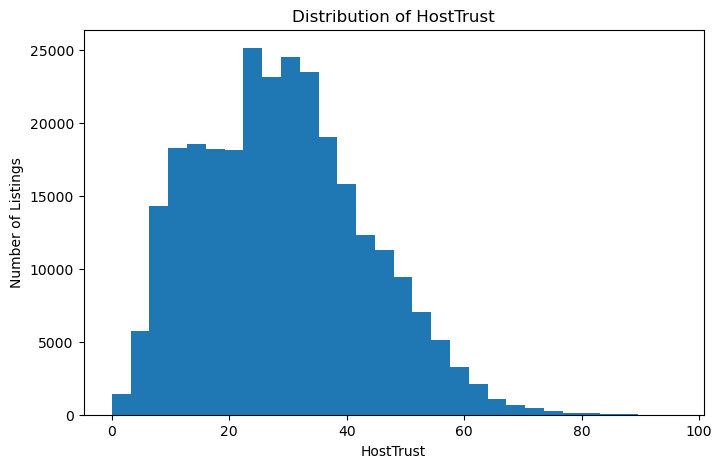

In [128]:
plt.figure(figsize=(8,5))

plt.hist(listings_fe["HostTrust"], bins=30)

plt.title("Distribution of HostTrust")
plt.xlabel("HostTrust")
plt.ylabel("Number of Listings")

plt.show()

In [129]:
host_validation = (
    listings_fe
    .groupby(
        pd.qcut(
            listings_fe["HostTrust"],
            5
        )
    )["review_scores_rating"]
    .agg(["count","mean","median","std"])
)
host_validation

C:\Users\Parv Gupta\AppData\Local\Temp\ipykernel_5180\21904121.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(


,count,mean,median,std
HostTrust,,,,
"(0.0125, 15.561]",27751,90.088862,95.0,14.880038
"(15.561, 24.584]",35133,92.089261,95.0,11.173421
"(24.584, 32.01]",37679,92.914886,95.0,9.620174
"(32.01, 40.989]",40732,94.152976,96.0,8.241753
"(40.989, 95.955]",46904,96.098307,98.0,5.776955


In [130]:
listings_fe[
    [
        "host_experience_score",
        "host_response_rate_score",
        "host_acceptance_rate_score",
        "superhost_score",
        "identity_score",
        "response_time_score"
    ]
].isna().sum()

host_experience_score              0
host_response_rate_score      128536
host_acceptance_rate_score    112857
superhost_score                    0
identity_score                     0
response_time_score           128536
dtype: int64

In [131]:
listings_fe["HostTrust"].isna().sum()

np.int64(0)

In [132]:
listings_fe["HostTrust"].notna().sum()

np.int64(279434)

In [133]:
listings_fe["HostTrust"].describe()

count    279434.000000
mean         29.080200
std          14.156633
min           0.013483
25%          17.985930
50%          28.328820
75%          38.272440
max          95.955188
Name: HostTrust, dtype: float64

In [134]:
listings_fe.to_csv("HostTrust_Output.csv", index=False)

In [135]:
listings_fe.head()

,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood,city,latitude,longitude,property_type,room_type,accommodates,bedrooms,amenities,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,host_response_rate_pct,response_rate_group,acceptance_rate_pct,acceptance_rate_group,host_experience_years,experience_group,host_experience_score,host_response_rate_score,host_acceptance_rate_score,superhost_score,identity_score,response_time_score,HostTrust,HostTrust_Components_Used
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",NaN,NaN,NaN,False,1.0,True,False,Buttes-Montmartre,Paris,48.88668,2.33343,Entire apartment,Entire place,2,1.0,"[""Heating"", ""Kitchen"", ""Washer"", ""Wifi"", ""Long...",53,2,1125.0,100.0,10.0,10.0,10.0,10.0,10.0,10.0,False,NaN,NaN,NaN,NaN,14.592745,13+ Years,0.736302,NaN,NaN,0,0,NaN,45.477167,3
1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,2013-11-29,"Paris, Ile-de-France, France",NaN,NaN,NaN,False,1.0,True,True,Buttes-Montmartre,Paris,48.88617,2.34515,Entire apartment,Entire place,2,1.0,"[""Shampoo"", ""Heating"", ""Kitchen"", ""Essentials""...",120,2,1125.0,100.0,10.0,10.0,10.0,10.0,10.0,10.0,False,NaN,NaN,NaN,NaN,12.602327,11-13 Years,0.577603,NaN,NaN,0,1,NaN,42.189042,3
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",NaN,NaN,NaN,False,1.0,True,False,Elysee,Paris,48.88112,2.31712,Entire apartment,Entire place,2,1.0,"[""Heating"", ""TV"", ""Kitchen"", ""Washer"", ""Wifi"",...",89,2,1125.0,100.0,10.0,10.0,10.0,10.0,10.0,10.0,False,NaN,NaN,NaN,NaN,11.934292,11-13 Years,0.524340,NaN,NaN,0,0,NaN,32.385460,3
3,4797344,Cosy studio (close to Eiffel tower),10668311,2013-12-17,"Paris, Ile-de-France, France",NaN,NaN,NaN,False,1.0,True,True,Vaugirard,Paris,48.84571,2.30584,Entire apartment,Entire place,2,1.0,"[""Heating"", ""TV"", ""Kitchen"", ""Wifi"", ""Long ter...",58,2,1125.0,100.0,10.0,10.0,10.0,10.0,10.0,10.0,False,NaN,NaN,NaN,NaN,12.553046,11-13 Years,0.573674,NaN,NaN,0,1,NaN,41.946353,3
4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,2014-12-14,"Paris, Ile-de-France, France",NaN,NaN,NaN,False,1.0,True,False,Passy,Paris,48.85500,2.26979,Entire apartment,Entire place,2,1.0,"[""Heating"", ""TV"", ""Kitchen"", ""Essentials"", ""Ha...",60,2,1125.0,100.0,10.0,10.0,10.0,10.0,10.0,10.0,False,NaN,NaN,NaN,NaN,11.561944,11-13 Years,0.494652,NaN,NaN,0,0,NaN,30.551812,3
